In [1]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold

from data_preprocessing.get_stnthetic_data import *

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)  # ✅ Set your global seed here

## Load dataset

#### Synthetic data

In [2]:
train_set_bs, test_set_bs, train_set_ps, test_set_ps, train_set_po, test_set_po = get_synthetic_data(n= 2000, file="/Users/ccy/Documents/CMU/Spring2025/42687 Projects in Biomedical AI/Final Project/Explainable Deep Learning on Multimodal Patient Data for Predicting Immunotherapy Outcomes in Metastatic Non-small Cell Lung Cancer/Synthetic data/PCA/rfe_50.csv" ,train_set_ratio=0.7, k=3)

# Change the input here
def input(train):
    X = train.iloc[:, 1:-1].values
    print(X.shape)
    
    # Standardize the features
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)
    
    target_col = train.columns[-1]
    print(target_col)
    y = train[target_col].values
    print("Label distribution:", Counter(y))
    return X, y

X, y = input(train_set_po)

(2000, 49)
Progression occurrence
Label distribution: Counter({0.0: 1000, 1.0: 1000})


### Define MLP

In [3]:
# Define MLP Model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_dims=[16, 8, 4], dropout=0.3):
        super(MLP, self).__init__()
        layers = []
        in_dim = input_size
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.model(x))

### Training

In [4]:
def cross_validate_models(X_scaled, y, model_configs, num_epochs=100, batch_size=64):
    """
    Perform stratified k-fold cross-validation for multiple model configurations,
    computing F1 score, accuracy, and AUC for both training and validation sets.

    Args:
        X_scaled (np.ndarray): Scaled feature matrix.
        y (np.ndarray): Target labels.
        model_configs (list of dict): List of model configuration dictionaries. Each dict must have:
            - 'hidden_dims': list of int for hidden layer sizes
            - 'dropout': float dropout rate
        num_epochs (int): Number of training epochs per fold.
        batch_size (int): Batch size for data loaders.

    Returns:
        list of dict: Model configurations with added average metrics, sorted by training F1 descending.
    """
    results = []

    for config in model_configs:
        print(f"\n🔍 Testing model config: {config}")

        # Initialize stratified k-fold with 10 splits
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

        # Prepare lists to collect metrics for each fold
        train_f1_scores, val_f1_scores = [], []
        train_acc_scores, val_acc_scores = [], []
        train_auc_scores, val_auc_scores = [], []

        # Iterate over each fold
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
            # Split features and labels
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # Convert to PyTorch tensors
            X_train_t = torch.tensor(X_train, dtype=torch.float32)
            X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
            y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
            y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

            # Create data loaders for training and validation
            train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False)

            # Initialize the model, loss criterion, and optimizer
            model = MLP(input_size=X_scaled.shape[1], hidden_dims=config["hidden_dims"], dropout=config["dropout"])
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)

            # Collect probabilities and true labels on the training set for AUC
            all_train_probs, all_train_labels = [], []
            for epoch in range(num_epochs):
                model.train()
                for inputs, labels in train_loader:
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                # After training for an epoch, record probabilities and labels
                with torch.no_grad():
                    for inputs, labels in train_loader:
                        probs = model(inputs).cpu().numpy().ravel()
                        all_train_probs .extend(probs)
                        all_train_labels.extend(labels.cpu().numpy().ravel())

            # Binarize probabilities at 0.5 threshold for classification metrics
            train_preds = (np.array(all_train_probs) > 0.5).astype(float)

            # Compute training metrics: F1, accuracy, AUC
            t_f1  = f1_score(all_train_labels, train_preds)
            t_acc = accuracy_score(all_train_labels, train_preds)
            t_auc = roc_auc_score(all_train_labels, all_train_probs)
            train_f1_scores.append(t_f1)
            train_acc_scores.append(t_acc)
            train_auc_scores.append(t_auc)

            # Evaluate on validation set: collect probabilities and labels
            model.eval()
            all_val_probs, all_val_labels = [], []
            with torch.no_grad():
                for inputs, labels in val_loader:
                    probs = model(inputs).cpu().numpy().ravel()
                    all_val_probs .extend(probs)
                    all_val_labels.extend(labels.cpu().numpy().ravel())

            # Binarize validation probabilities for F1 and accuracy
            val_preds = (np.array(all_val_probs) > 0.5).astype(float)

            # Compute validation metrics: F1, accuracy, AUC
            v_f1  = f1_score(all_val_labels, val_preds)
            v_acc = accuracy_score(all_val_labels, val_preds)
            v_auc = roc_auc_score(all_val_labels, all_val_probs)
            val_f1_scores.append(v_f1)
            val_acc_scores.append(v_acc)
            val_auc_scores.append(v_auc)

            print(
                f"Fold {fold+1}: Train F1={t_f1:.4f}, Val F1={v_f1:.4f}, "
                f"Train AUC={t_auc:.4f}, Val AUC={v_auc:.4f}"
            )

        # Average metrics across all folds
        config['avg_train_acc'] = np.mean(train_acc_scores)
        config['avg_val_acc']   = np.mean(val_acc_scores)
        config['avg_train_f1']  = np.mean(train_f1_scores)
        config['avg_val_f1']    = np.mean(val_f1_scores)
        config['avg_train_auc'] = np.mean(train_auc_scores)
        config['avg_val_auc']   = np.mean(val_auc_scores)

        # Print summary of average metrics
        print(f"✅ Config {config['hidden_dims']} → "
              f"Train acc: {config['avg_train_acc']:.4f}, Val acc: {config['avg_val_acc']:.4f}")
        print(f"✅ Config {config['hidden_dims']} → "
              f"Train F1: {config['avg_train_f1']:.4f}, Val F1: {config['avg_val_f1']:.4f}")
        print(f"✅ Config {config['hidden_dims']} → "
              f"Train AUC: {config['avg_train_auc']:.4f}, Val AUC: {config['avg_val_auc']:.4f}")

        results.append(config)

    # Sort results by average training F1 in descending order
    return sorted(results, key=lambda x: x['avg_train_f1'], reverse=True)


In [5]:
def train_final_model(X_scaled, y, hidden_dims, dropout=0.3, num_epochs=100, batch_size=64, save_path="final_model.pt"):
    print("\n🚀 Training final model with best config...")
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = MLP(input_size=X_scaled.shape[1], hidden_dims=hidden_dims, dropout=dropout)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)
    #scheduler = StepLR(optimizer, step_size=50, gamma=0.9)

    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        #scheduler.step()
    torch.save(model.state_dict(), save_path)
    print(f"✅ Final model saved to {save_path}")
    return model


In [6]:
def plot_roc(fpr, tpr, roc_auc): 
    
    plt.plot(fpr, tpr, lw=2, alpha=0.8, label=f'Test ROC (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve on Test Set')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()


In [7]:
def evaluate_on_test(model, X_test, y_test):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        probs = outputs.cpu().numpy()
        preds = (outputs > 0.5).float().cpu().numpy()
        labels = y_test_tensor.cpu().numpy()
        

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    
    plot_roc(fpr,tpr,roc_auc)
    
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    #auc = roc_auc_score(labels, preds)
    print(f"\n🧪 Final Evaluation on Test Set:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC:{roc_auc: .4f}")


In [8]:
model_configs = [
    {"hidden_dims": [16, 8, 4], "dropout": 0.3},
    {"hidden_dims": [32, 16], "dropout": 0.3},
    {"hidden_dims": [64, 32], "dropout": 0.2},
    {"hidden_dims": [16, 8], "dropout": 0.3}
]

# Step 1: Select the best model
sorted_configs = cross_validate_models(X, y, model_configs)


🔍 Testing model config: {'hidden_dims': [16, 8, 4], 'dropout': 0.3}
Fold 1: Train F1=0.9214, Val F1=1.0000, Train AUC=0.9865, Val AUC=1.0000
Fold 2: Train F1=0.9183, Val F1=1.0000, Train AUC=0.9844, Val AUC=1.0000
Fold 3: Train F1=0.9476, Val F1=1.0000, Train AUC=0.9897, Val AUC=1.0000
Fold 4: Train F1=0.9077, Val F1=1.0000, Train AUC=0.9749, Val AUC=1.0000
Fold 5: Train F1=0.9228, Val F1=1.0000, Train AUC=0.9730, Val AUC=1.0000
Fold 6: Train F1=0.9539, Val F1=1.0000, Train AUC=0.9811, Val AUC=1.0000
Fold 7: Train F1=0.9310, Val F1=1.0000, Train AUC=0.9885, Val AUC=1.0000
Fold 8: Train F1=0.9272, Val F1=1.0000, Train AUC=0.9870, Val AUC=1.0000
Fold 9: Train F1=0.9283, Val F1=1.0000, Train AUC=0.9870, Val AUC=1.0000
Fold 10: Train F1=0.9304, Val F1=1.0000, Train AUC=0.9756, Val AUC=1.0000
✅ Config [16, 8, 4] → Train acc: 0.9264, Val acc: 1.0000
✅ Config [16, 8, 4] → Train F1: 0.9289, Val F1: 1.0000
✅ Config [16, 8, 4] → Train AUC: 0.9828, Val AUC: 1.0000

🔍 Testing model config: {'hidd

best config: {'hidden_dims': [64, 32], 'dropout': 0.2, 'avg_train_acc': 0.9901783333333334, 'avg_val_acc': 1.0, 'avg_train_f1': 0.9901589936595663, 'avg_val_f1': 1.0, 'avg_train_auc': 0.9996552796111111, 'avg_val_auc': 1.0}

🚀 Training final model with best config...
✅ Final model saved to final_model.pt
(22, 49)
Progression occurrence
Label distribution: Counter({0.0: 16, 1.0: 6})


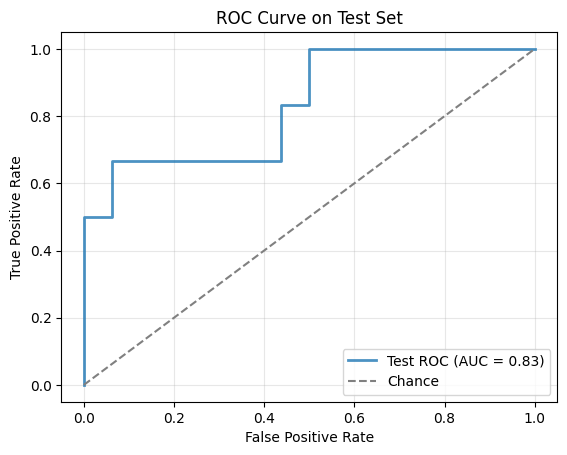


🧪 Final Evaluation on Test Set:
Accuracy: 0.8182, Precision: 0.6667, Recall: 0.6667, F1: 0.6667, AUC: 0.8333


In [9]:
best_config = sorted_configs[0]
print(f"best config: {best_config}")

# Step 2: retrain best model on full training set
final_model = train_final_model(X, y, hidden_dims=best_config['hidden_dims'], dropout=best_config['dropout'])

# Step 3: test set
X_test, y_test = input(test_set_po)
evaluate_on_test(final_model, X_test, y_test)